In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

base_path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

files = {
    "diam.csv": 0,
    "jalan.csv": 1,
    "diamjatuh.csv": 2,
    "jalanjatuh.csv": 3
}

window_size = 200
step_size = 100

X = []
y = []

for file, label in files.items():

    file_path = os.path.join(
        base_path,
        file
    )

    df = pd.read_csv(file_path)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    scaler = StandardScaler()

    data = scaler.fit_transform(data)

    for i in range(
        0,
        len(data) - window_size,
        step_size
    ):

        window = data[
            i:i + window_size
        ]

        X.append(window)

        y.append(label)

X = np.array(X)

y = np.array(y)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (2392, 200, 3)
Shape y : (2392,)


In [ ]:
# PREPROCESSING ACCELEROMETER ONLY
# WINDOW 200

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_200/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200
stride = 200

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 200")
print("Saved to:", save_path)

Processing: diam
Window: 300
Processing: jalan
Window: 300
Processing: diamjatuh
Window: 300
Processing: jalanjatuh
Window: 300
Shape X : (1200, 200, 3)
Shape y : (1200,)
Train : (960, 200, 3)
Test  : (240, 200, 3)
Dataset ACC ONLY Window 200
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_200/


Train : (960, 200, 3)
Test  : (240, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 13: finished saving model to best_model_acc_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7005 - loss: 0.6888 - val_accuracy: 0.5521 - val_loss: 1.0138 - learning_rate: 5.0000e-04
Epoch 14/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6795 - loss: 0.7852
Epoch 14: val_accuracy did not improve from 0.55208
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7044 - loss: 0.6998 - val_accuracy: 0.5521 - val_loss: 0.9162 - learning_rate: 5.0000e-04
Epoch 15/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6959 - loss: 0.6657
Epoch 15: val_accuracy improved from 0.55208 to 0.56250, saving model to best_model_acc_only_200.h5



Epoch 15: finished saving model to best_model_acc_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7240 - loss: 0.6594 - val_accuracy: 0.5625 - val_loss: 0.9221 - learning_rate: 5.0000e-04
Epoch 16/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7110 - loss: 0.6725
Epoch 16: val_accuracy improved from 0.56250 to 0.63021, saving model to best_model_acc_only_200.h5



Epoch 16: finished saving model to best_model_acc_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7161 - loss: 0.6691 - val_accuracy: 0.6302 - val_loss: 0.8530 - learning_rate: 5.0000e-04
Epoch 17/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7377 - loss: 0.6354
Epoch 17: val_accuracy did not improve from 0.63021
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7318 - loss: 0.6231 - val_accuracy: 0.5885 - val_loss: 0.8330 - learning_rate: 5.0000e-04
Epoch 18/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7404 - loss: 0.5776
Epoch 18: val_accuracy did not improve from 0.63021
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7396 - loss: 0.5944 - val_accuracy: 0.6094 - val_loss: 0.7700 - learning_rate: 5.0000e-04
Epoch 19/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7471 - loss: 0.6014
Epoch 19: val_accuracy did not improve from 0.63021
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7435 - loss: 0.6066 - val_accuracy


Epoch 22: finished saving model to best_model_acc_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7786 - loss: 0.5288 - val_accuracy: 0.6615 - val_loss: 0.7861 - learning_rate: 5.0000e-04
Epoch 23/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7778 - loss: 0.5111
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_accuracy did not improve from 0.66146
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7760 - loss: 0.5420 - val_accuracy: 0.6562 - val_loss: 0.7999 - learning_rate: 5.0000e-04
Epoch 24/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7502 - loss: 0.5567
Epoch 24: val_accuracy did not improve from 0.66146
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7656 - loss: 0.5308 - val_accuracy: 0.6458 - val_loss: 0.7749 - learning_rate: 2.5000e-04
Epoch 25/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8105 - loss: 0.4336
Epoch 25: val_accuracy did not improve from 0.66146
24/24 ━━━━


Epoch 28: finished saving model to best_model_acc_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8346 - loss: 0.4244 - val_accuracy: 0.6771 - val_loss: 0.7764 - learning_rate: 2.5000e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7208 - loss: 0.7106
TEST ACCURACY : 72.08 %
TEST LOSS     : 0.7106
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.72      0.87      0.79        60
       jalan       0.76      0.80      0.78        60
   diamjatuh       0.62      0.72      0.67        60
  jalanjatuh       0.83      0.50      0.62        60

    accuracy                           0.72       240
   macro avg       0.74      0.72      0.72       240
weighted avg       0.74      0.72      0.72       240



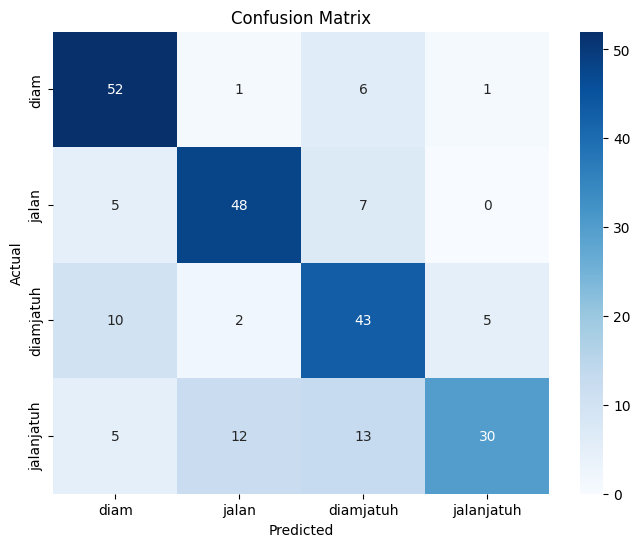

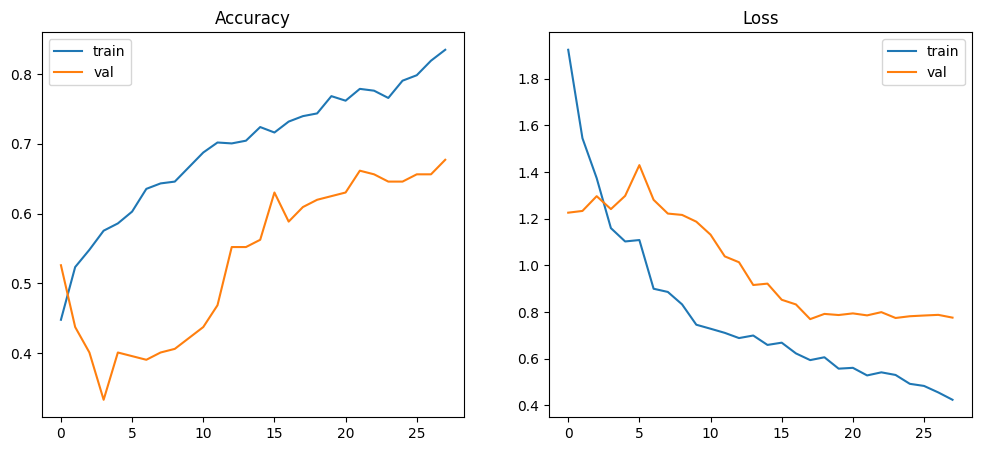

In [ ]:
# TRAINING CNN ACC ONLY 200

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_200.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 300

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_300/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 300
stride = 300

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 300")
print("Saved to:", save_path)

Processing: diam
Window: 200
Processing: jalan
Window: 200
Processing: diamjatuh
Window: 200
Processing: jalanjatuh
Window: 200
Shape X : (800, 300, 3)
Shape y : (800,)
Train : (640, 300, 3)
Test  : (160, 300, 3)
Dataset ACC ONLY Window 300
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_300/


Train : (640, 300, 3)
Test  : (160, 300, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 296, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,404 (2.34 MB)

...


Epoch 20: finished saving model to best_model_acc_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8047 - loss: 0.5272 - val_accuracy: 0.6641 - val_loss: 0.8030 - learning_rate: 5.0000e-04
Epoch 21/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7962 - loss: 0.5068
Epoch 21: val_accuracy did not improve from 0.66406
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8047 - loss: 0.5092 - val_accuracy: 0.6641 - val_loss: 0.7935 - learning_rate: 5.0000e-04
Epoch 22/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8175 - loss: 0.4455
Epoch 22: val_accuracy did not improve from 0.66406
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8223 - loss: 0.4633 - val_accuracy: 0.6562 - val_loss: 0.7933 - learning_rate: 5.0000e-04
Epoch 23/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7850 - loss: 0.5555
Epoch 23: val_accuracy improved from 0.66406 to 0.68750, saving model to best_model_acc_only_300.h5



Epoch 23: finished saving model to best_model_acc_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7715 - loss: 0.5782 - val_accuracy: 0.6875 - val_loss: 0.7846 - learning_rate: 5.0000e-04
Epoch 24/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8406 - loss: 0.4628
Epoch 24: val_accuracy did not improve from 0.68750
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8008 - loss: 0.4909 - val_accuracy: 0.6797 - val_loss: 0.7072 - learning_rate: 5.0000e-04
Epoch 25/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8310 - loss: 0.4173
Epoch 25: val_accuracy improved from 0.68750 to 0.71875, saving model to best_model_acc_only_300.h5



Epoch 25: finished saving model to best_model_acc_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8457 - loss: 0.4137 - val_accuracy: 0.7188 - val_loss: 0.7543 - learning_rate: 5.0000e-04
Epoch 26/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8580 - loss: 0.3557
Epoch 26: val_accuracy did not improve from 0.71875
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8379 - loss: 0.4039 - val_accuracy: 0.6875 - val_loss: 0.7344 - learning_rate: 5.0000e-04
Epoch 27/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8447 - loss: 0.4092
Epoch 27: val_accuracy did not improve from 0.71875
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8301 - loss: 0.4178 - val_accuracy: 0.6719 - val_loss: 0.7449 - learning_rate: 5.0000e-04
Epoch 28/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7795 - loss: 0.5507
Epoch 28: val_accuracy did not improve from 0.71875
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7773 - loss: 0.5062 - val_accuracy


Epoch 30: finished saving model to best_model_acc_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8496 - loss: 0.3980 - val_accuracy: 0.7500 - val_loss: 0.6936 - learning_rate: 2.5000e-04
Epoch 31/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8478 - loss: 0.3317
Epoch 31: val_accuracy did not improve from 0.75000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8535 - loss: 0.3258 - val_accuracy: 0.7031 - val_loss: 0.7171 - learning_rate: 2.5000e-04
Epoch 32/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8616 - loss: 0.3788
Epoch 32: val_accuracy did not improve from 0.75000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8477 - loss: 0.4036 - val_accuracy: 0.6797 - val_loss: 0.7343 - learning_rate: 2.5000e-04
Epoch 33/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8266 - loss: 0.3709
Epoch 33: val_accuracy did not improve from 0.75000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8457 - loss: 0.3490 - val_accuracy

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 

Classification Report:

              precision    recall  f1-score   support

        diam       0.70      0.82      0.76        40
       jalan       0.77      0.90      0.83        40
   diamjatuh       0.49      0.45      0.47        40
  jalanjatuh       0.52      0.38      0.43        40

    accuracy                           0.64       160
   macro avg       0.62      0.64      0.62       160
weighted avg       0.62      0.64      0.62       160



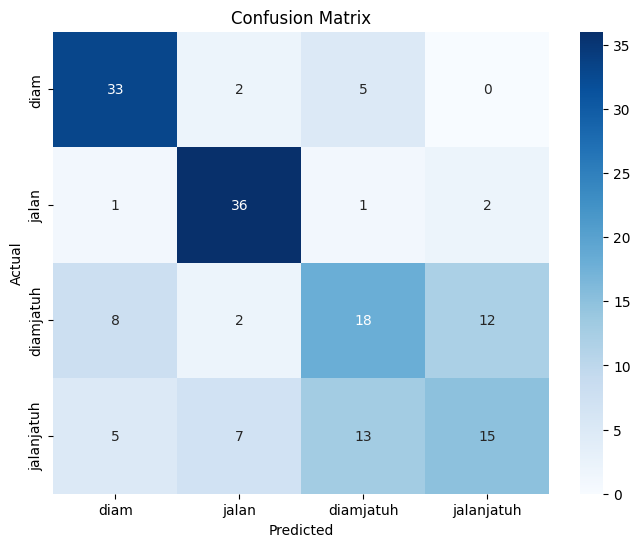

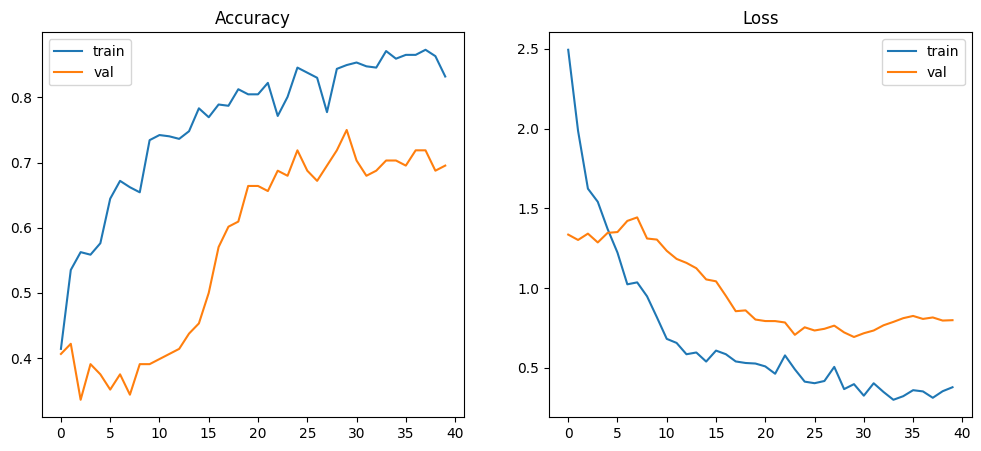

In [ ]:
# TRAINING CNN ACC ONLY 300

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_300/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_300.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 400

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_400/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 400
stride = 400

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 400")
print("Saved to:", save_path)

Processing: diam
Window: 150
Processing: jalan
Window: 150
Processing: diamjatuh
Window: 150
Processing: jalanjatuh
Window: 150
Shape X : (600, 400, 3)
Shape y : (600,)
Train : (480, 400, 3)
Test  : (120, 400, 3)
Dataset ACC ONLY Window 400
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_400/


Train : (480, 400, 3)
Test  : (120, 400, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 396, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 396, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 196, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 96, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       786,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,396 (3.16 MB)

...

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4197 - loss: 2.2332
Epoch 1: val_accuracy improved from None to 0.31250, saving model to best_model_acc_only_400.h5



Epoch 1: finished saving model to best_model_acc_only_400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.4609 - loss: 2.3818 - val_accuracy: 0.3125 - val_loss: 1.3653 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5027 - loss: 2.2883
Epoch 2: val_accuracy improved from 0.31250 to 0.51042, saving model to best_model_acc_only_400.h5



Epoch 2: finished saving model to best_model_acc_only_400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5365 - loss: 2.1619 - val_accuracy: 0.5104 - val_loss: 1.2173 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6253 - loss: 1.6955
Epoch 3: val_accuracy did not improve from 0.51042
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5521 - loss: 1.9482 - val_accuracy: 0.5000 - val_loss: 1.1984 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5966 - loss: 1.3509
Epoch 4: val_accuracy did not improve from 0.51042
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5859 - loss: 1.5540 - val_accuracy: 0.3333 - val_loss: 1.3062 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6761 - loss: 1.1182
Epoch 5: val_accuracy did not improve from 0.51042
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6615 - loss: 1.1905 - val_accuracy: 0.2500 - val_loss

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.60      0.40      0.48        30
       jalan       0.75      0.90      0.82        30
   diamjatuh       0.34      0.63      0.44        30
  jalanjatuh       0.50      0.13      0.21        30

    accuracy                           0.52       120
   macro avg       0.55      0.52      0.49       120
weighted avg       0.55      0.52      0.49       120



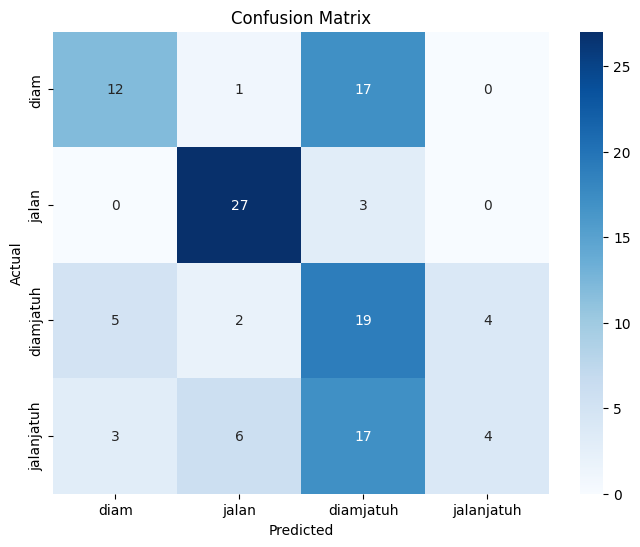

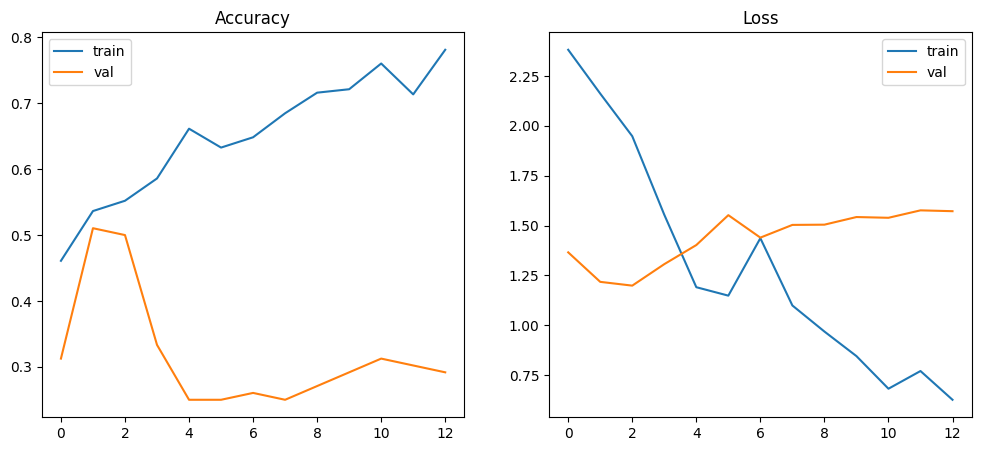

In [ ]:
# TRAINING CNN ACC ONLY 400

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_400/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(400,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_400.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 150

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_150/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 150
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 150")
print("Saved to:", save_path)

Processing: diam
Window: 400
Processing: jalan
Window: 400
Processing: diamjatuh
Window: 400
Processing: jalanjatuh
Window: 400
Shape X : (1600, 150, 3)
Shape y : (1600,)
Train : (1280, 150, 3)
Test  : (320, 150, 3)
Dataset ACC ONLY Window 150
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_150/


Train : (1280, 150, 3)
Test  : (320, 150, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 146, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 146, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 73, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 71, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 71, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 33, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 33, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,108 (1.16 MB)

...


Epoch 11: finished saving model to best_model_acc_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6680 - loss: 0.7822 - val_accuracy: 0.6055 - val_loss: 0.8781 - learning_rate: 0.0010
Epoch 12/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6759 - loss: 0.7663
Epoch 12: val_accuracy improved from 0.60547 to 0.64062, saving model to best_model_acc_only_150.h5



Epoch 12: finished saving model to best_model_acc_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6748 - loss: 0.7875 - val_accuracy: 0.6406 - val_loss: 0.8801 - learning_rate: 0.0010
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7113 - loss: 0.7064
Epoch 13: val_accuracy improved from 0.64062 to 0.67578, saving model to best_model_acc_only_150.h5



Epoch 13: finished saving model to best_model_acc_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7021 - loss: 0.7144 - val_accuracy: 0.6758 - val_loss: 0.8004 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6832 - loss: 0.7699
Epoch 14: val_accuracy did not improve from 0.67578
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6719 - loss: 0.7800 - val_accuracy: 0.6562 - val_loss: 0.8253 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7209 - loss: 0.7155
Epoch 15: val_accuracy improved from 0.67578 to 0.70703, saving model to best_model_acc_only_150.h5



Epoch 15: finished saving model to best_model_acc_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7012 - loss: 0.7327 - val_accuracy: 0.7070 - val_loss: 0.7806 - learning_rate: 0.0010
Epoch 16/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7075 - loss: 0.7152
Epoch 16: val_accuracy did not improve from 0.70703
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6885 - loss: 0.6985 - val_accuracy: 0.6680 - val_loss: 0.7707 - learning_rate: 0.0010
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7136 - loss: 0.6323
Epoch 17: val_accuracy did not improve from 0.70703
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7227 - loss: 0.6427 - val_accuracy: 0.6758 - val_loss: 0.8657 - learning_rate: 0.0010
Epoch 18/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7527 - loss: 0.6004
Epoch 18: val_accuracy did not improve from 0.70703
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7480 - loss: 0.6017 - val_accuracy: 0.6602 - v


Epoch 23: finished saving model to best_model_acc_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7754 - loss: 0.5191 - val_accuracy: 0.7227 - val_loss: 0.8476 - learning_rate: 5.0000e-04
Epoch 24/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7997 - loss: 0.4908
Epoch 24: val_accuracy did not improve from 0.72266
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7891 - loss: 0.4934 - val_accuracy: 0.6602 - val_loss: 0.8801 - learning_rate: 5.0000e-04
Epoch 25/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7613 - loss: 0.4995
Epoch 25: val_accuracy did not improve from 0.72266
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7832 - loss: 0.4926 - val_accuracy: 0.6953 - val_loss: 0.8873 - learning_rate: 5.0000e-04
Epoch 26/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7786 - loss: 0.4941
Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 26: val_accuracy did not improve from 0.72266
32/32 ━━━━

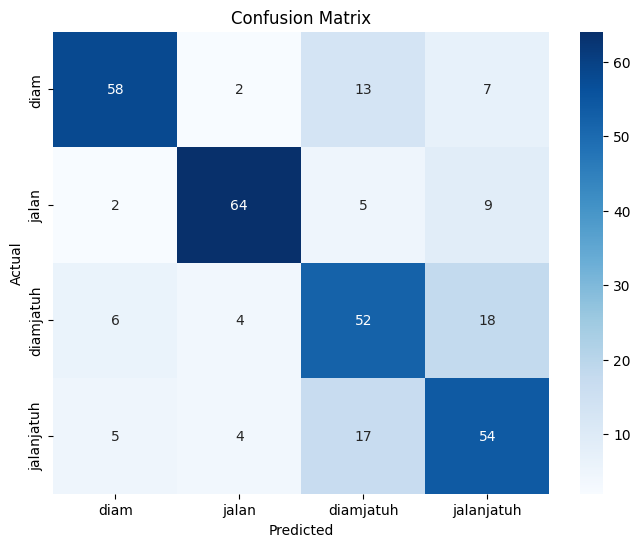

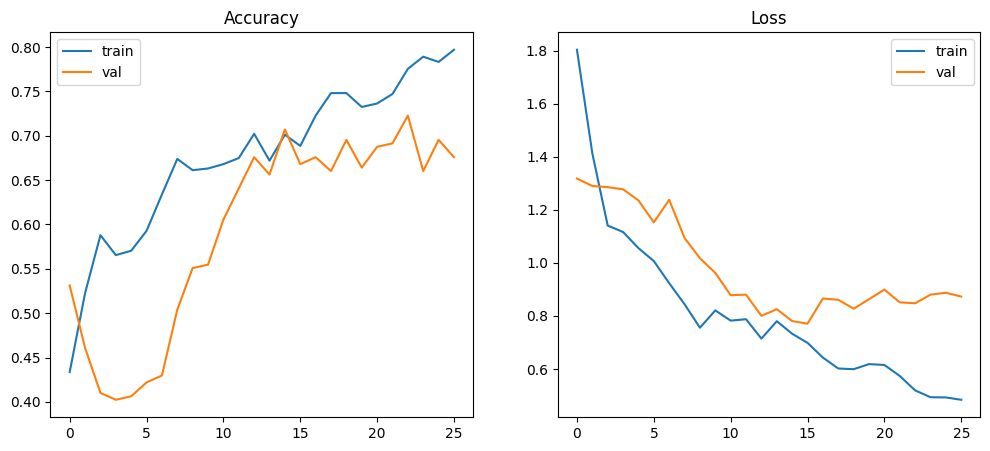

In [ ]:
# TRAINING CNN ACC ONLY 150

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_150/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(150,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_150.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 250

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_250/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 250
stride = 250

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 250")
print("Saved to:", save_path)

Processing: diam
Window: 240
Processing: jalan
Window: 240
Processing: diamjatuh
Window: 240
Processing: jalanjatuh
Window: 240
Shape X : (960, 250, 3)
Shape y : (960,)
Train : (768, 250, 3)
Test  : (192, 250, 3)
Dataset ACC ONLY Window 250
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_250/


Train : (768, 250, 3)
Test  : (192, 250, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 246, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 246, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 123, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 121, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 121, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 58, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 58, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       475,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,100 (1.97 MB)

...


Epoch 14: finished saving model to best_model_acc_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6515 - loss: 0.8324 - val_accuracy: 0.5844 - val_loss: 0.9144 - learning_rate: 0.0010
Epoch 15/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6706 - loss: 0.8157
Epoch 15: val_accuracy did not improve from 0.58442
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6775 - loss: 0.7896 - val_accuracy: 0.5519 - val_loss: 0.9502 - learning_rate: 0.0010
Epoch 16/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7181 - loss: 0.7582
Epoch 16: val_accuracy did not improve from 0.58442
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7003 - loss: 0.7886 - val_accuracy: 0.5649 - val_loss: 0.8826 - learning_rate: 0.0010
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6711 - loss: 0.8427
Epoch 17: val_accuracy did not improve from 0.58442
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6450 - loss: 0.8788 - val_accuracy: 0.5844 - v


Epoch 19: finished saving model to best_model_acc_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6840 - loss: 0.7154 - val_accuracy: 0.5909 - val_loss: 0.8032 - learning_rate: 0.0010
Epoch 20/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7170 - loss: 0.6711
Epoch 20: val_accuracy did not improve from 0.59091
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7182 - loss: 0.6960 - val_accuracy: 0.5909 - val_loss: 0.7868 - learning_rate: 0.0010
Epoch 21/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7032 - loss: 0.6505
Epoch 21: val_accuracy improved from 0.59091 to 0.64286, saving model to best_model_acc_only_250.h5



Epoch 21: finished saving model to best_model_acc_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7182 - loss: 0.6623 - val_accuracy: 0.6429 - val_loss: 0.7477 - learning_rate: 0.0010
Epoch 22/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7166 - loss: 0.5762
Epoch 22: val_accuracy did not improve from 0.64286
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7248 - loss: 0.6125 - val_accuracy: 0.6364 - val_loss: 0.7644 - learning_rate: 0.0010
Epoch 23/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7643 - loss: 0.6146
Epoch 23: val_accuracy did not improve from 0.64286
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7443 - loss: 0.6294 - val_accuracy: 0.5974 - val_loss: 0.8227 - learning_rate: 0.0010
Epoch 24/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7853 - loss: 0.5196
Epoch 24: val_accuracy did not improve from 0.64286
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7622 - loss: 0.5686 - val_accuracy: 0.6234 - v


Epoch 27: finished saving model to best_model_acc_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7769 - loss: 0.5051 - val_accuracy: 0.6623 - val_loss: 0.7702 - learning_rate: 5.0000e-04
Epoch 28/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7839 - loss: 0.5511
Epoch 28: val_accuracy improved from 0.66234 to 0.67532, saving model to best_model_acc_only_250.h5



Epoch 28: finished saving model to best_model_acc_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7915 - loss: 0.5439 - val_accuracy: 0.6753 - val_loss: 0.7789 - learning_rate: 5.0000e-04
Epoch 29/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8155 - loss: 0.4471
Epoch 29: val_accuracy did not improve from 0.67532
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8029 - loss: 0.4696 - val_accuracy: 0.6299 - val_loss: 0.7882 - learning_rate: 5.0000e-04
Epoch 30/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7836 - loss: 0.4790
Epoch 30: val_accuracy did not improve from 0.67532
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8257 - loss: 0.4176 - val_accuracy: 0.6429 - val_loss: 0.7962 - learning_rate: 5.0000e-04
Epoch 31/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7890 - loss: 0.5026
Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: val_accuracy did not improve from 0.67532
20/20 ━━━━

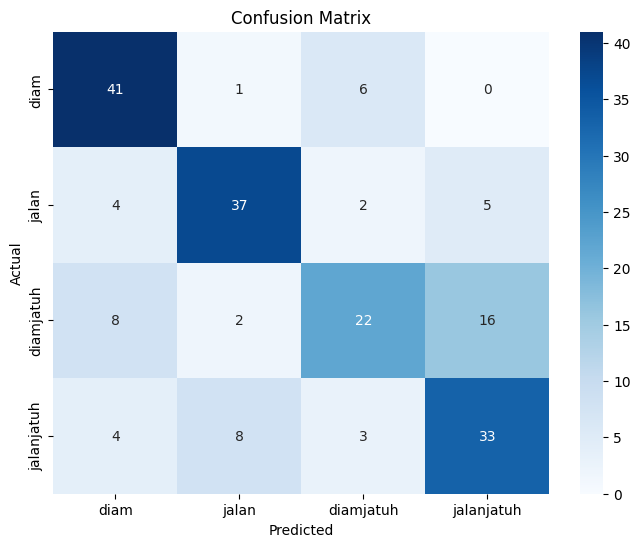

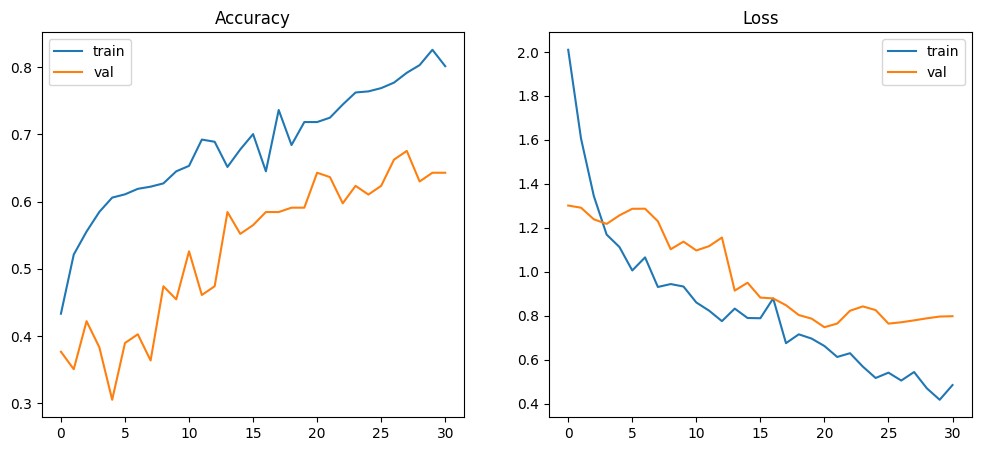

In [ ]:
# TRAINING CNN ACC ONLY 250

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_250/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(250,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_250.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 200 OVERLAP 50%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap50/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200
stride = 100

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 200 Overlap 50%")
print("Saved to:", save_path)

Processing: diam
Window: 599
Processing: jalan
Window: 599
Processing: diamjatuh
Window: 599
Processing: jalanjatuh
Window: 599
Shape X : (2396, 200, 3)
Shape y : (2396,)
Train : (1916, 200, 3)
Test  : (480, 200, 3)
Dataset ACC ONLY Window 200 Overlap 50%
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_200_overlap50/


Train : (1916, 200, 3)
Test  : (480, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 12: finished saving model to best_model_acc_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7102 - loss: 0.7056 - val_accuracy: 0.6979 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 13/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7188 - loss: 0.6672
Epoch 13: val_accuracy improved from 0.69792 to 0.70833, saving model to best_model_acc_only_200_overlap50.h5



Epoch 13: finished saving model to best_model_acc_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7115 - loss: 0.6848 - val_accuracy: 0.7083 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 14/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7197 - loss: 0.6987
Epoch 14: val_accuracy did not improve from 0.70833
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7252 - loss: 0.6627 - val_accuracy: 0.6797 - val_loss: 0.7496 - learning_rate: 0.0010
Epoch 15/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7281 - loss: 0.5968
Epoch 15: val_accuracy did not improve from 0.70833
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7402 - loss: 0.6010 - val_accuracy: 0.7031 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 16/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7408 - loss: 0.6265
Epoch 16: val_accuracy did not improve from 0.70833
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7376 - loss: 0.6090 - val_accuracy: 


Epoch 17: finished saving model to best_model_acc_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7461 - loss: 0.5862 - val_accuracy: 0.7292 - val_loss: 0.6540 - learning_rate: 0.0010
Epoch 18/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7585 - loss: 0.5547
Epoch 18: val_accuracy did not improve from 0.72917
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7598 - loss: 0.5546 - val_accuracy: 0.7005 - val_loss: 0.7094 - learning_rate: 0.0010
Epoch 19/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7751 - loss: 0.5439
Epoch 19: val_accuracy did not improve from 0.72917
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7617 - loss: 0.5787 - val_accuracy: 0.7161 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 20/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7765 - loss: 0.5299
Epoch 20: val_accuracy improved from 0.72917 to 0.73698, saving model to best_model_acc_only_200_overlap50.h5



Epoch 20: finished saving model to best_model_acc_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7787 - loss: 0.5181 - val_accuracy: 0.7370 - val_loss: 0.7061 - learning_rate: 0.0010
Epoch 21/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7678 - loss: 0.5372
Epoch 21: val_accuracy did not improve from 0.73698
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7722 - loss: 0.5216 - val_accuracy: 0.6979 - val_loss: 0.7408 - learning_rate: 0.0010
Epoch 22/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7886 - loss: 0.5048
Epoch 22: val_accuracy did not improve from 0.73698
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7852 - loss: 0.5196 - val_accuracy: 0.7083 - val_loss: 0.7503 - learning_rate: 0.0010
Epoch 23/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8105 - loss: 0.4427
Epoch 23: val_accuracy did not improve from 0.73698
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8003 - loss: 0.4699 - val_accuracy: 


Epoch 26: finished saving model to best_model_acc_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8368 - loss: 0.3922 - val_accuracy: 0.7708 - val_loss: 0.6533 - learning_rate: 5.0000e-04
Epoch 27/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8214 - loss: 0.4009
Epoch 27: val_accuracy did not improve from 0.77083
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8355 - loss: 0.3836 - val_accuracy: 0.7344 - val_loss: 0.6984 - learning_rate: 5.0000e-04
Epoch 28/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8301 - loss: 0.3889
Epoch 28: val_accuracy did not improve from 0.77083
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8336 - loss: 0.3796 - val_accuracy: 0.7448 - val_loss: 0.6655 - learning_rate: 5.0000e-04
Epoch 29/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8318 - loss: 0.3755
Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 29: val_accuracy did not improve from 0.77083


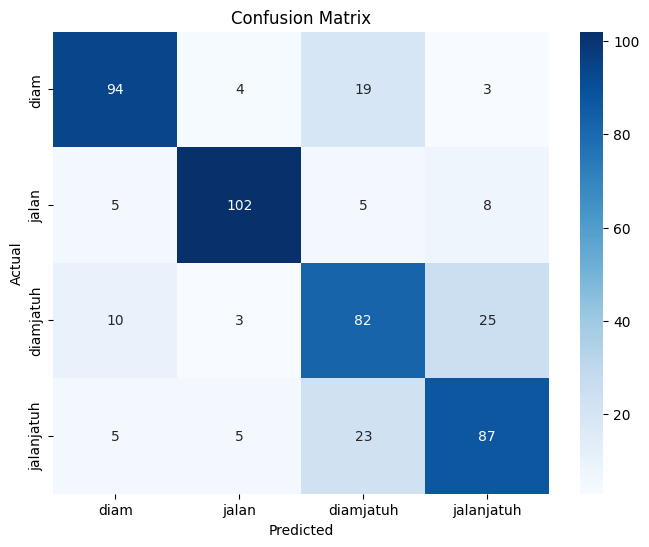

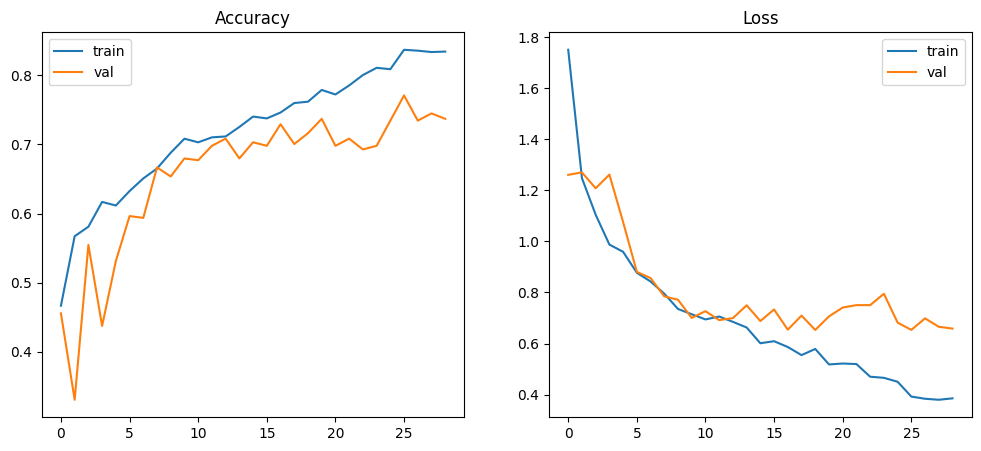

In [ ]:
# TRAINING CNN ACC ONLY 200 OVERLAP 50%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap50/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_200_overlap50.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 300 OVERLAP 50%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_300_overlap50/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 300
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 300 Overlap 50%")
print("Saved to:", save_path)

Processing: diam
Window: 399
Processing: jalan
Window: 399
Processing: diamjatuh
Window: 399
Processing: jalanjatuh
Window: 399
Shape X : (1596, 300, 3)
Shape y : (1596,)
Train : (1276, 300, 3)
Test  : (320, 300, 3)
Dataset ACC ONLY Window 300 Overlap 50%
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_300_overlap50/


Train : (1276, 300, 3)
Test  : (320, 300, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 296, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,404 (2.34 MB)

...


Epoch 10: finished saving model to best_model_acc_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7039 - loss: 0.7604 - val_accuracy: 0.5938 - val_loss: 1.0543 - learning_rate: 0.0010
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7021 - loss: 0.7242
Epoch 11: val_accuracy improved from 0.59375 to 0.60547, saving model to best_model_acc_only_300_overlap50.h5



Epoch 11: finished saving model to best_model_acc_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6980 - loss: 0.7286 - val_accuracy: 0.6055 - val_loss: 0.9319 - learning_rate: 0.0010
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6776 - loss: 0.7567
Epoch 12: val_accuracy improved from 0.60547 to 0.66797, saving model to best_model_acc_only_300_overlap50.h5



Epoch 12: finished saving model to best_model_acc_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6892 - loss: 0.7388 - val_accuracy: 0.6680 - val_loss: 0.8493 - learning_rate: 0.0010
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7167 - loss: 0.6683
Epoch 13: val_accuracy improved from 0.66797 to 0.72266, saving model to best_model_acc_only_300_overlap50.h5



Epoch 13: finished saving model to best_model_acc_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7275 - loss: 0.6599 - val_accuracy: 0.7227 - val_loss: 0.7861 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7062 - loss: 0.6472
Epoch 14: val_accuracy did not improve from 0.72266
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7255 - loss: 0.6415 - val_accuracy: 0.6914 - val_loss: 0.8315 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7493 - loss: 0.5873
Epoch 15: val_accuracy did not improve from 0.72266
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7422 - loss: 0.6321 - val_accuracy: 0.6953 - val_loss: 0.9207 - learning_rate: 0.0010
Epoch 16/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7509 - loss: 0.6048
Epoch 16: val_accuracy did not improve from 0.72266
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7480 - loss: 0.6045 - val_accuracy: 


Epoch 17: finished saving model to best_model_acc_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7637 - loss: 0.5681 - val_accuracy: 0.7617 - val_loss: 0.7772 - learning_rate: 0.0010
Epoch 18/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7431 - loss: 0.6289
Epoch 18: val_accuracy did not improve from 0.76172
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7647 - loss: 0.5669 - val_accuracy: 0.7109 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 19/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7508 - loss: 0.6490
Epoch 19: val_accuracy did not improve from 0.76172
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7618 - loss: 0.5824 - val_accuracy: 0.7031 - val_loss: 0.8630 - learning_rate: 0.0010
Epoch 20/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7945 - loss: 0.4784
Epoch 20: val_accuracy did not improve from 0.76172
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7853 - loss: 0.5080 - val_accuracy: 

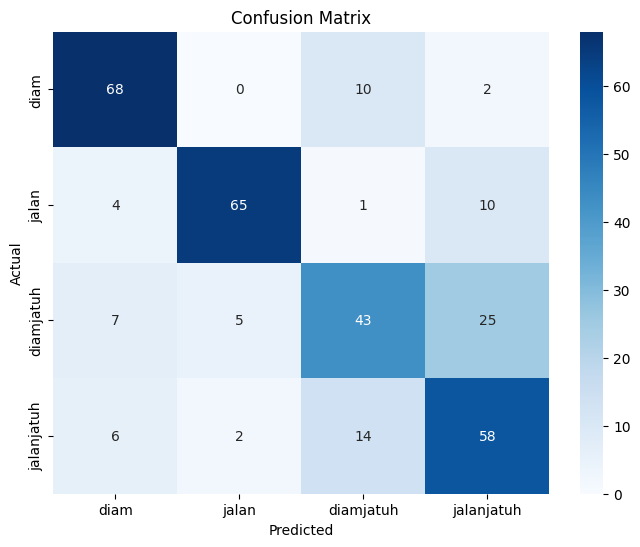

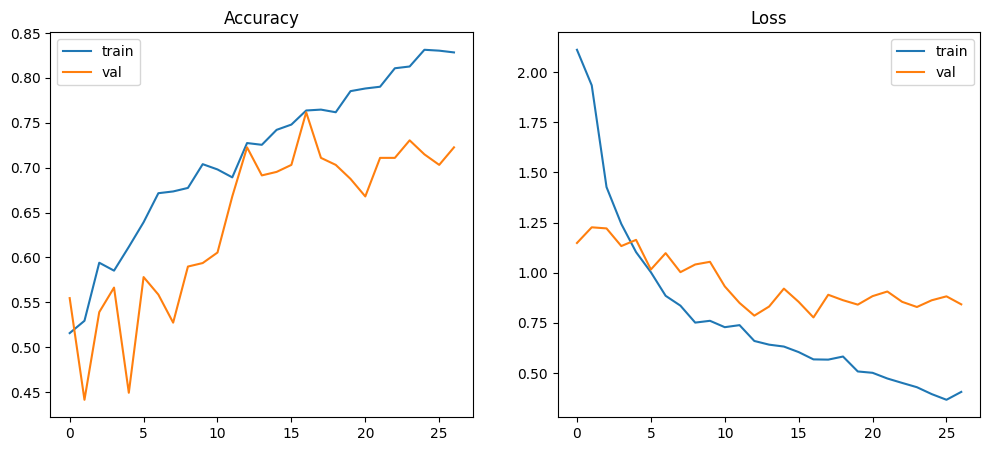

In [ ]:
# TRAINING CNN ACC ONLY 300 OVERLAP 50%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_300_overlap50/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_300_overlap50.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 200 OVERLAP 25%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap25/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 200 Overlap 25%")
print("Saved to:", save_path)

Processing: diam
Window: 399
Processing: jalan
Window: 399
Processing: diamjatuh
Window: 399
Processing: jalanjatuh
Window: 399
Shape X : (1596, 200, 3)
Shape y : (1596,)
Train : (1276, 200, 3)
Test  : (320, 200, 3)
Dataset ACC ONLY Window 200 Overlap 25%
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_200_overlap25/


Train : (1276, 200, 3)
Test  : (320, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_23 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 12: finished saving model to best_model_acc_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6853 - loss: 0.7557 - val_accuracy: 0.6562 - val_loss: 0.8543 - learning_rate: 0.0010
Epoch 13/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7069 - loss: 0.7293
Epoch 13: val_accuracy did not improve from 0.65625
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7059 - loss: 0.7343 - val_accuracy: 0.6289 - val_loss: 0.8748 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6590 - loss: 0.7298
Epoch 14: val_accuracy did not improve from 0.65625
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6814 - loss: 0.7091 - val_accuracy: 0.6562 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7273 - loss: 0.6494
Epoch 15: val_accuracy improved from 0.65625 to 0.67188, saving model to best_model_acc_only_200_overlap25.h5



Epoch 15: finished saving model to best_model_acc_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7265 - loss: 0.6484 - val_accuracy: 0.6719 - val_loss: 0.7514 - learning_rate: 0.0010
Epoch 16/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7336 - loss: 0.6213
Epoch 16: val_accuracy improved from 0.67188 to 0.69531, saving model to best_model_acc_only_200_overlap25.h5



Epoch 16: finished saving model to best_model_acc_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7314 - loss: 0.6259 - val_accuracy: 0.6953 - val_loss: 0.7598 - learning_rate: 0.0010
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7423 - loss: 0.6282
Epoch 17: val_accuracy did not improve from 0.69531
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7392 - loss: 0.6152 - val_accuracy: 0.6055 - val_loss: 0.7495 - learning_rate: 0.0010
Epoch 18/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7190 - loss: 0.6807
Epoch 18: val_accuracy improved from 0.69531 to 0.70703, saving model to best_model_acc_only_200_overlap25.h5



Epoch 18: finished saving model to best_model_acc_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7255 - loss: 0.6486 - val_accuracy: 0.7070 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 19/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7392 - loss: 0.6274
Epoch 19: val_accuracy did not improve from 0.70703
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7382 - loss: 0.6257 - val_accuracy: 0.6562 - val_loss: 0.8332 - learning_rate: 0.0010
Epoch 20/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7650 - loss: 0.5939
Epoch 20: val_accuracy improved from 0.70703 to 0.71094, saving model to best_model_acc_only_200_overlap25.h5



Epoch 20: finished saving model to best_model_acc_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7588 - loss: 0.6248 - val_accuracy: 0.7109 - val_loss: 0.7471 - learning_rate: 0.0010
Epoch 21/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7549 - loss: 0.5773
Epoch 21: val_accuracy did not improve from 0.71094
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7637 - loss: 0.5534 - val_accuracy: 0.7109 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 22/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7675 - loss: 0.5340
Epoch 22: val_accuracy did not improve from 0.71094
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7755 - loss: 0.5293 - val_accuracy: 0.6758 - val_loss: 0.7668 - learning_rate: 0.0010
Epoch 23/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7654 - loss: 0.5628
Epoch 23: val_accuracy did not improve from 0.71094
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7735 - loss: 0.5499 - val_accuracy: 

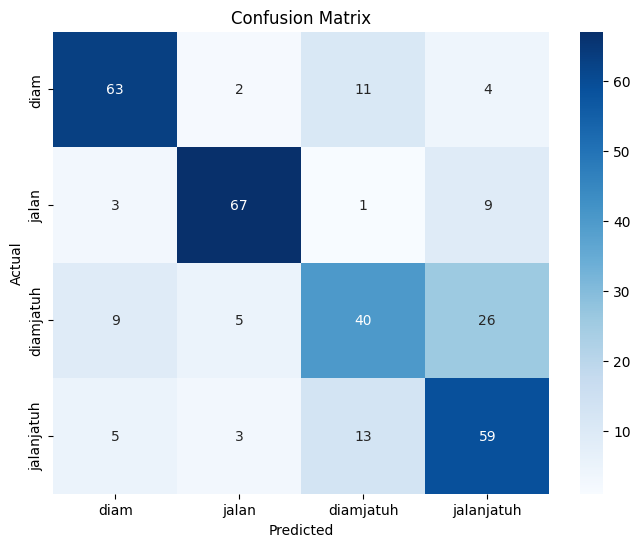

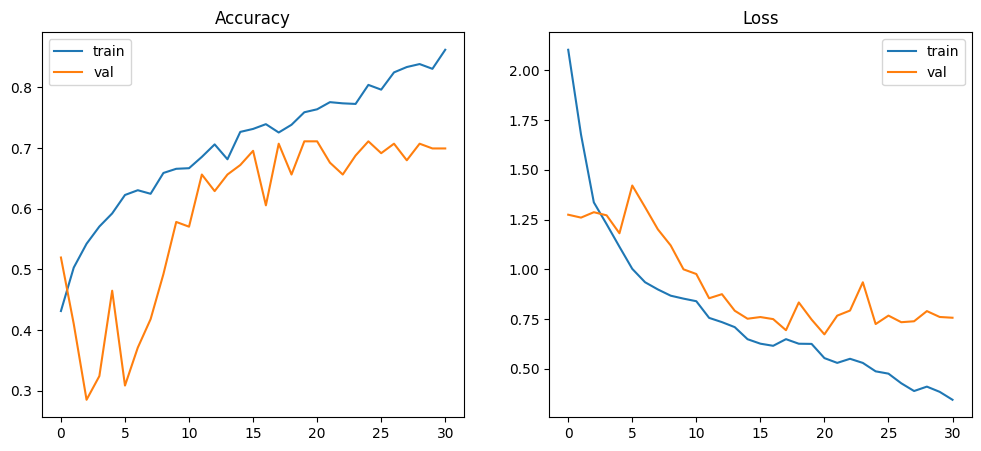

In [ ]:
# TRAINING CNN ACC ONLY 200 OVERLAP 25%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap25/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_200_overlap25.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

In [ ]:
# PREPROCESSING ACC ONLY
# WINDOW 200 OVERLAP 75%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/accelero_only/"

save_path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap75/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200
stride = 50

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "ax",
        "ay",
        "az"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data) - window + 1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)

        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

print("Dataset ACC ONLY Window 200 Overlap 75%")
print("Saved to:", save_path)

Processing: diam
Window: 1197
Processing: jalan
Window: 1197
Processing: diamjatuh
Window: 1197
Processing: jalanjatuh
Window: 1197
Shape X : (4788, 200, 3)
Shape y : (4788,)
Train : (3830, 200, 3)
Test  : (958, 200, 3)
Dataset ACC ONLY Window 200 Overlap 75%
Saved to: /content/drive/My Drive/Colab Notebooks/acc_only_200_overlap75/


Train : (3830, 200, 3)
Test  : (958, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 32: finished saving model to best_model_acc_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8593 - loss: 0.3233 - val_accuracy: 0.8238 - val_loss: 0.5194 - learning_rate: 5.0000e-04
Epoch 33/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8700 - loss: 0.2931
Epoch 33: val_accuracy did not improve from 0.82376
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8652 - loss: 0.3141 - val_accuracy: 0.7963 - val_loss: 0.5378 - learning_rate: 5.0000e-04
Epoch 34/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8727 - loss: 0.2993
Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 34: val_accuracy improved from 0.82376 to 0.82637, saving model to best_model_acc_only_200_overlap75.h5



Epoch 34: finished saving model to best_model_acc_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8708 - loss: 0.3059 - val_accuracy: 0.8264 - val_loss: 0.5474 - learning_rate: 5.0000e-04
Epoch 35/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8890 - loss: 0.2734
Epoch 35: val_accuracy improved from 0.82637 to 0.82898, saving model to best_model_acc_only_200_overlap75.h5



Epoch 35: finished saving model to best_model_acc_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8959 - loss: 0.2585 - val_accuracy: 0.8290 - val_loss: 0.5234 - learning_rate: 2.5000e-04
Epoch 36/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8818 - loss: 0.2745
Epoch 36: val_accuracy did not improve from 0.82898
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8838 - loss: 0.2639 - val_accuracy: 0.8146 - val_loss: 0.5260 - learning_rate: 2.5000e-04
Epoch 37/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9162 - loss: 0.2175
Epoch 37: val_accuracy improved from 0.82898 to 0.83159, saving model to best_model_acc_only_200_overlap75.h5



Epoch 37: finished saving model to best_model_acc_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9021 - loss: 0.2348 - val_accuracy: 0.8316 - val_loss: 0.5091 - learning_rate: 2.5000e-04
Epoch 38/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8983 - loss: 0.2404
Epoch 38: val_accuracy did not improve from 0.83159
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8985 - loss: 0.2386 - val_accuracy: 0.8277 - val_loss: 0.5371 - learning_rate: 2.5000e-04
Epoch 39/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8962 - loss: 0.2340
Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 39: val_accuracy improved from 0.83159 to 0.83290, saving model to best_model_acc_only_200_overlap75.h5



Epoch 39: finished saving model to best_model_acc_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9063 - loss: 0.2384 - val_accuracy: 0.8329 - val_loss: 0.5310 - learning_rate: 2.5000e-04
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7933 - loss: 0.5134
TEST ACCURACY : 79.33 %
TEST LOSS     : 0.5134
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.84      0.85      0.85       240
       jalan       0.87      0.85      0.86       239
   diamjatuh       0.67      0.81      0.73       240
  jalanjatuh       0.83      0.66      0.74       239

    accuracy                           0.79       958
   macro avg       0.80      0.79      0.79       958
weighted avg       0.80      0.79      0.79       958



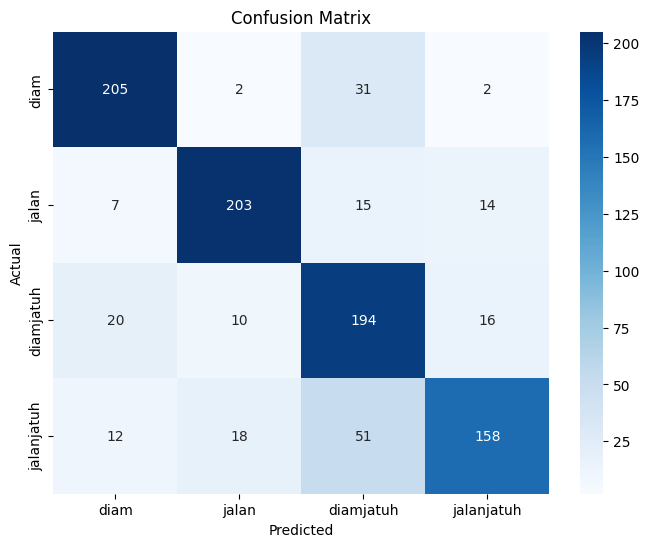

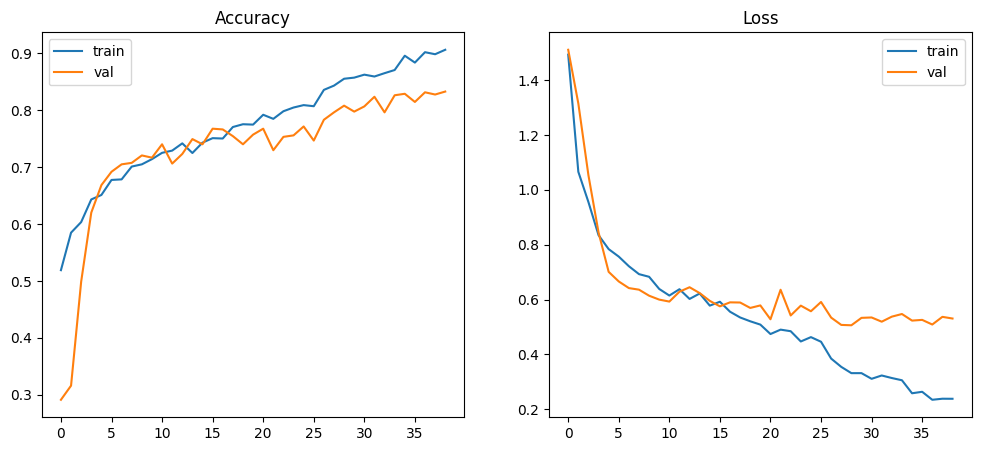

In [ ]:
# TRAINING CNN ACC ONLY 200 OVERLAP 75%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap75/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(

        monitor='val_loss',

        patience=10,

        restore_best_weights=True
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    ModelCheckpoint(

        "best_model_acc_only_200_overlap75.h5",

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=kelas,

    yticklabels=kelas
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")

plt.legend()

plt.show()

KELAS : DIAM
Jumlah Window : 1197
ax -> Dominant Freq = 1.000 Hz | Power = 0.01102
ay -> Dominant Freq = 1.000 Hz | Power = 0.00482
az -> Dominant Freq = 1.000 Hz | Power = 0.01003


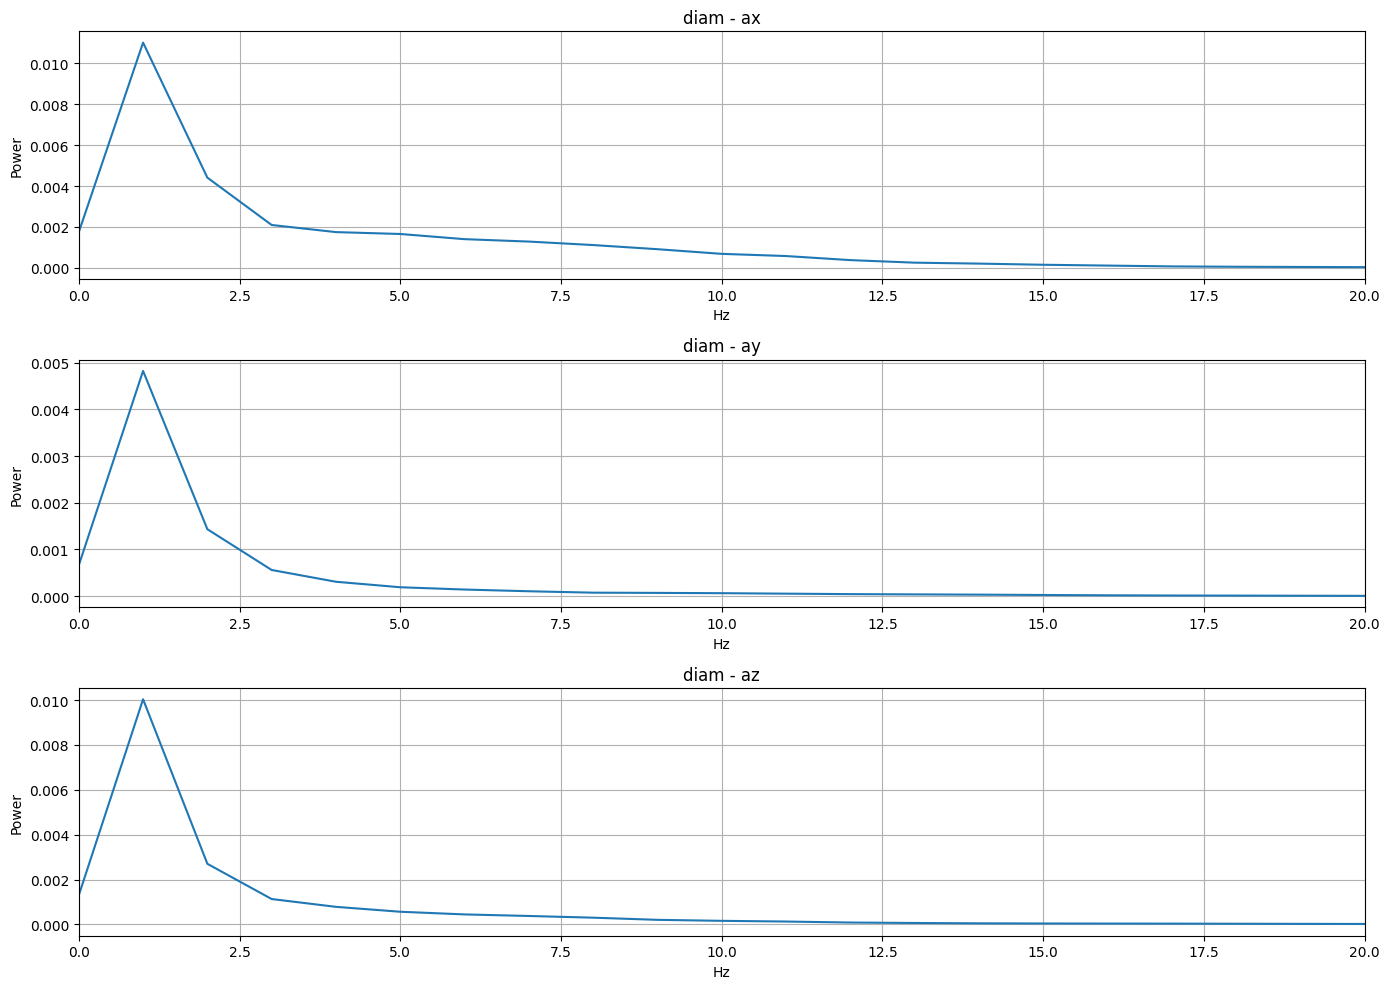

KELAS : JALAN
Jumlah Window : 1197
ax -> Dominant Freq = 1.000 Hz | Power = 0.04925
ay -> Dominant Freq = 1.000 Hz | Power = 0.03282
az -> Dominant Freq = 1.000 Hz | Power = 0.03457


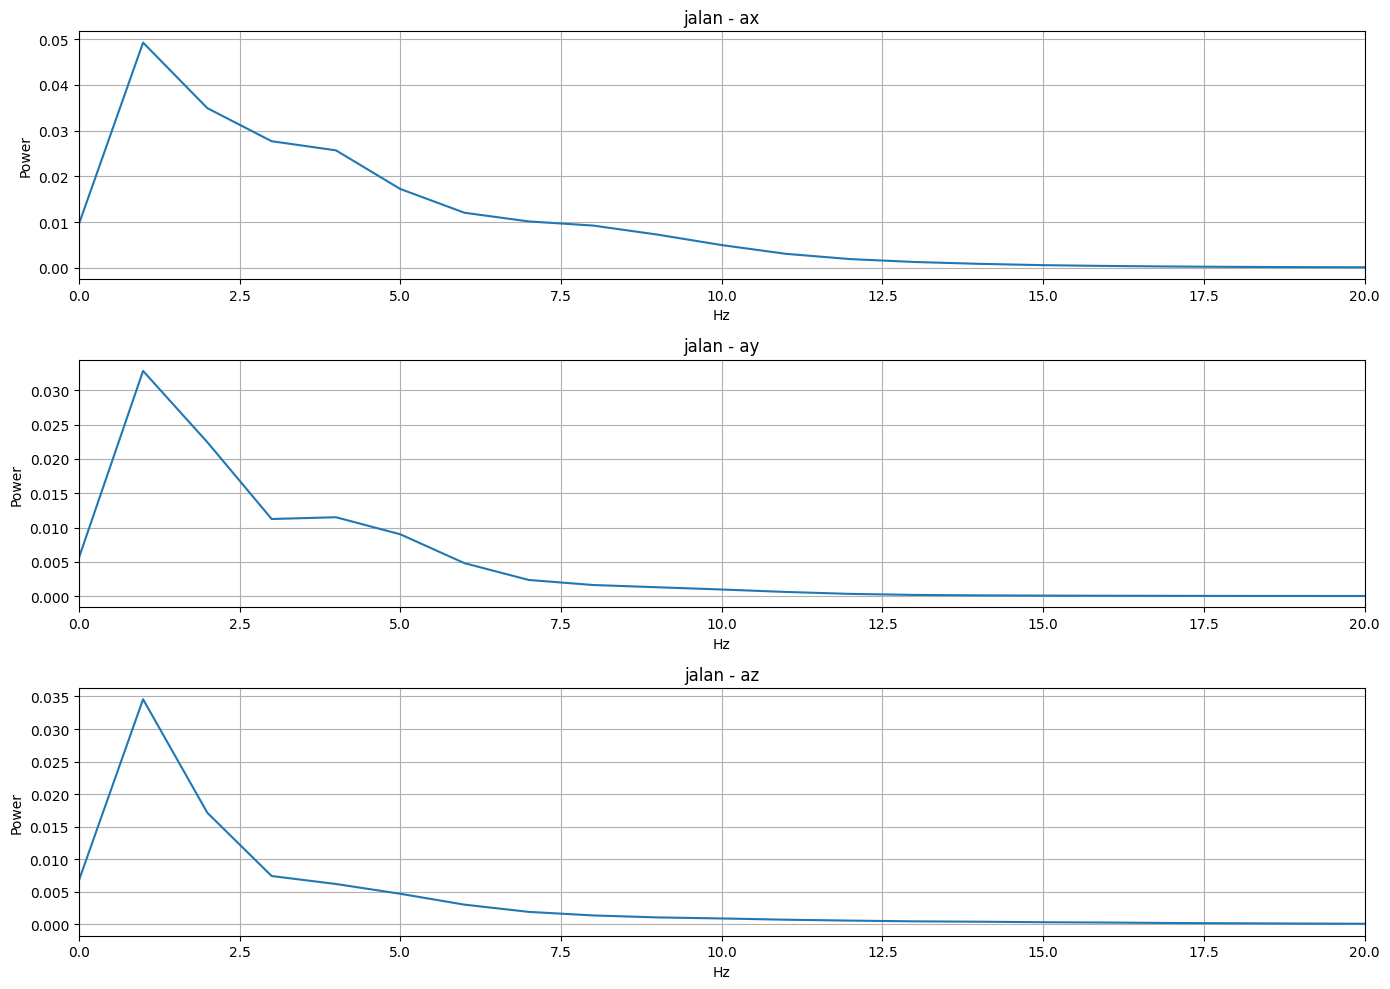

KELAS : DIAMJATUH
Jumlah Window : 1197
ax -> Dominant Freq = 1.000 Hz | Power = 0.05336
ay -> Dominant Freq = 1.000 Hz | Power = 0.02870
az -> Dominant Freq = 1.000 Hz | Power = 0.03629


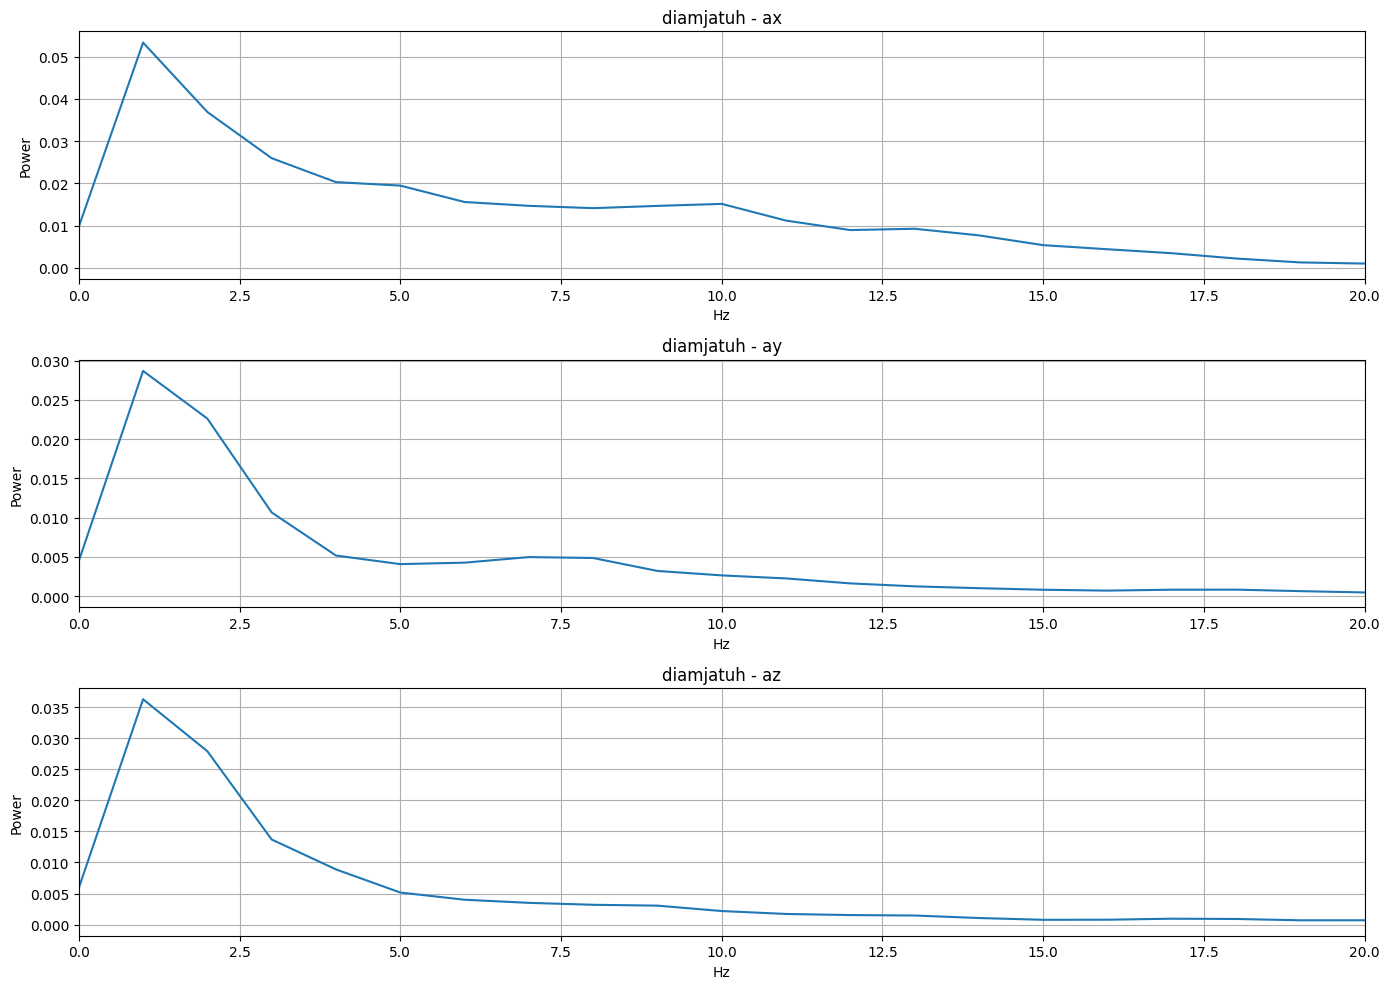

KELAS : JALANJATUH
Jumlah Window : 1197
ax -> Dominant Freq = 1.000 Hz | Power = 0.08505
ay -> Dominant Freq = 1.000 Hz | Power = 0.06229
az -> Dominant Freq = 1.000 Hz | Power = 0.06333


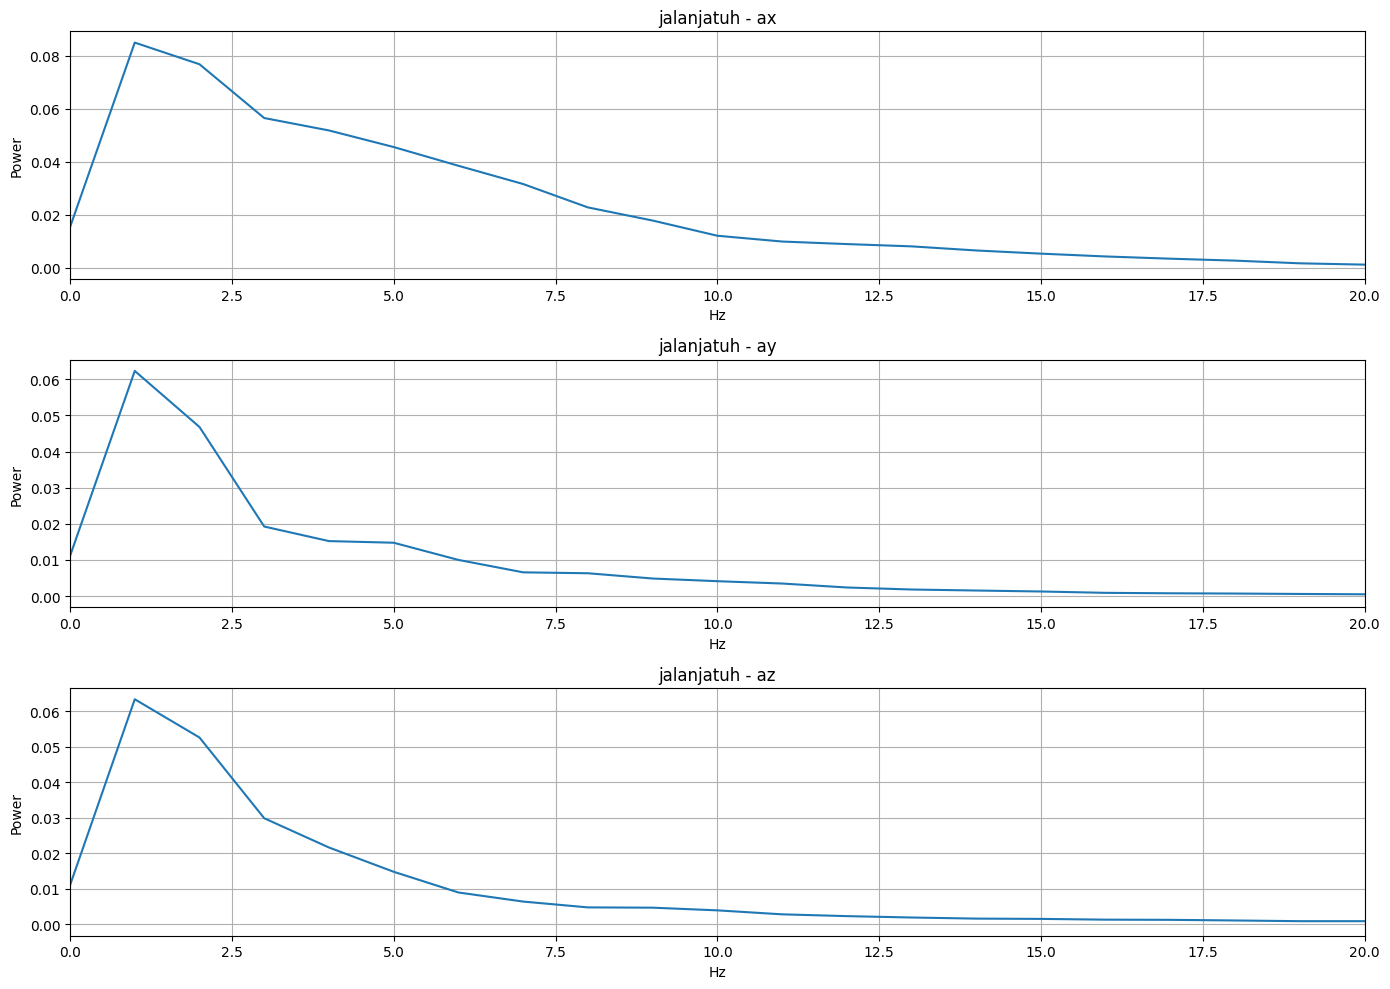

In [ ]:
# PSA ACC ONLY
# WINDOW 200 OVERLAP 75%
# DATASET MODEL TERBAIK

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch

fs = 200

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap75/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

X = np.concatenate(
    [X_train, X_test],
    axis=0
)

y = np.concatenate(
    [y_train, y_test],
    axis=0
)

kelas = {
    0: "diam",
    1: "jalan",
    2: "diamjatuh",
    3: "jalanjatuh"
}

channels = [
    "ax",
    "ay",
    "az"
]

for label in range(4):

    idx = np.where(y == label)[0]

    data_kelas = X[idx]

    print("KELAS :", kelas[label].upper())
    print("Jumlah Window :", len(data_kelas))

    fig, axs = plt.subplots(3,1, figsize=(14,10))

    for ch in range(3):

        psd_all = []

        for sample in data_kelas:

            signal = sample[:, ch]

            freq, psd = welch(
                signal,
                fs=fs,
                nperseg=200
            )

            psd_all.append(psd)

        psd_mean = np.mean(
            psd_all,
            axis=0
        )

        idx_peak = np.argmax(psd_mean[1:]) + 1

        dom_freq = freq[idx_peak]
        dom_power = psd_mean[idx_peak]

        print(
            f"{channels[ch]} -> Dominant Freq = {dom_freq:.3f} Hz | Power = {dom_power:.5f}"
        )

        axs[ch].plot(freq, psd_mean)

        axs[ch].set_title(
            f"{kelas[label]} - {channels[ch]}"
        )

        axs[ch].set_xlabel("Hz")
        axs[ch].set_ylabel("Power")
        axs[ch].set_xlim(0,20)
        axs[ch].grid(True)

    plt.tight_layout()
    plt.show()

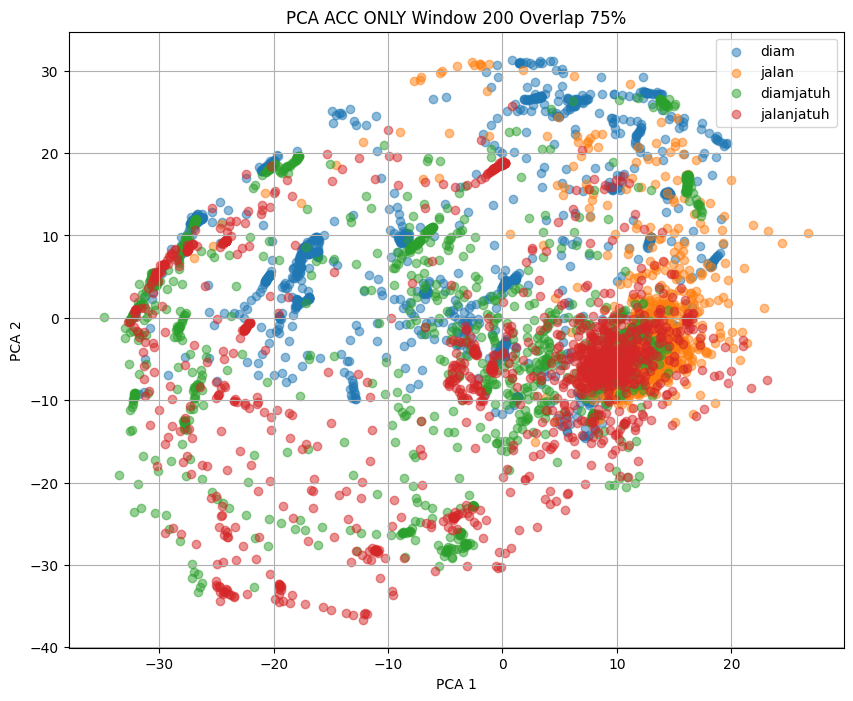

Explained Variance PCA1 : 36.56 %
Explained Variance PCA2 : 25.57 %
Total Variance : 62.12 %


In [ ]:
# PCA ACC ONLY
# MODEL TERBAIK : WINDOW 200 OVERLAP 75%

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/acc_only_200_overlap75/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

X = np.concatenate(
    [X_train, X_test],
    axis=0
)

y = np.concatenate(
    [y_train, y_test],
    axis=0
)

n_sample = X.shape[0]

X_flat = X.reshape(
    n_sample,
    -1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_flat)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

kelas = {
    0: "diam",
    1: "jalan",
    2: "diamjatuh",
    3: "jalanjatuh"
}

plt.figure(figsize=(10,8))

for label in np.unique(y):

    idx = y == label

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        alpha=0.5,
        label=kelas[label]
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("PCA ACC ONLY Window 200 Overlap 75%")

plt.legend()

plt.grid(True)

plt.show()

print("Explained Variance PCA1 :", round(pca.explained_variance_ratio_[0]*100,2), "%")
print("Explained Variance PCA2 :", round(pca.explained_variance_ratio_[1]*100,2), "%")
print("Total Variance :", round(sum(pca.explained_variance_ratio_)*100,2), "%")
